# Week4_ex5_analysis - Rotating Coil in a Uniform Field: Flux Linkage, Torque and Back-EMF

![Week4_ex5 result](Images/Week4_ex5_result_image.png)

A 200 x 200 mm square coil (10 turns modeled as one stranded 2 mm conductor, 10 A) sits in a uniform B = 1 T along x, set up with tangential-H boundaries on the y/z faces and zero tangential H on the x faces. The coil is rotated about the y axis in 100 steps of 3.6 deg and solved as Magnetostatic at each angle. The back-EMF column comes from a finite difference of the flux linkage, with one revolution taken as one 10 Hz electrical period.

Everything here has a closed form, so this checks the amplitudes, and also that torque and back-EMF are consistent with each other the way energy conversion requires (k_T = k_E). There's no anomaly to chase. The CSV was already known when this was written, so there are no blind predictions.

$$\Lambda(\theta)=NBA\sin\theta,\qquad T(\theta)=I\frac{d\Lambda}{d\theta}=NIAB\cos\theta,\qquad e=-\frac{d\Lambda}{dt}=-\omega NBA\cos\theta,\qquad T\omega+eI=0$$

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. 100-step rotation results exported by the original notebook
df = pd.read_csv("Week4_ex5_result.csv")
theta = np.deg2rad(df["angle [degree]"].values)
lam = df["flux linkage [Wb]"].values
T_total = df["total torque [N.m]"].values
emf = df["B-emf [V]"].values

# 2. Model constants (from the original notebook's design variables)
N, I, B = 10, 10.0, 1.0
a = 0.2
A = a * a
w = 2 * np.pi * 10.0               # one revolution per electrical period
step = 2 * np.pi / len(theta)
dt = step / w

lam_max = N * B * A
T_max = N * I * A * B
e_max = w * lam_max

In [2]:
# 3. Least-squares fit of c0 + c1*sin(theta) + c2*cos(theta) to flux linkage and torque
M = np.column_stack([np.ones_like(theta), np.sin(theta), np.cos(theta)])
c_lam = np.linalg.lstsq(M, lam, rcond=None)[0]
c_T = np.linalg.lstsq(M, T_total, rcond=None)[0]

lam_amp = np.hypot(c_lam[1], c_lam[2])
T_amp = np.hypot(c_T[1], c_T[2])

pd.DataFrame({
    "quantity": ["flux linkage amplitude [Wb]", "torque amplitude [N.m]", "torque on line 1 / line 2, peak [N.m]", "torque on line 3, peak [N.m]"],
    "theory": [lam_max, T_max, T_max / 2, 0.0],
    "FEM": [lam_amp, T_amp, df["torque line 1 [N.m]"].abs().max(), df["torque line 3 [N.m]"].abs().max()],
    "FEM vs theory [%]": [(lam_amp / lam_max - 1) * 100, (T_amp / T_max - 1) * 100,
                          (df["torque line 1 [N.m]"].abs().max() / (T_max / 2) - 1) * 100, np.nan],
    "phase error [deg]": [np.rad2deg(np.arctan2(c_lam[2], c_lam[1])), np.rad2deg(np.arctan2(-c_T[1], c_T[2])), np.nan, np.nan],
    "constant offset": [c_lam[0], c_T[0], np.nan, np.nan],
}).round(5)

,quantity,theory,FEM,FEM vs theory [%],phase error [deg],constant offset
0,flux linkage amplitude [Wb],0.4,0.39999,-0.00133,-0.00010,0.00080
1,torque amplitude [N.m],4.0,3.99558,-0.11046,-0.00087,0.00002
2,"torque on line 1 / line 2, peak [N.m]",2.0,1.99588,-0.20577,NaN,NaN
3,"torque on line 3, peak [N.m]",0.0,0.00464,NaN,NaN,NaN


![Week4_ex5 torque vs angle](Images/Week4_ex5_torque.png)

![Week4_ex5 flux linkage and back-EMF vs angle](Images/Week4_ex5_flux_bemf.png)

These two plots from the original notebook show the whole sweep at once: line 1 and line 2 overlap almost exactly and add up to the total torque, line 3 stays flat at zero, and the back-EMF crosses zero right where the flux linkage peaks, as -dLambda/dt should. What they can't show is how close the amplitudes are, or the small constant offset in the flux linkage - at this scale 0.8 mWb is invisible, and the annotated max/min only give two digits. Those come from the fit above.

Once the constant offset is separated out, the flux-linkage amplitude matches NBA to 0.001%, the torque amplitude is 0.11% low, and both phase errors are under 0.001 deg. The 0.4008 Wb peak in the original plot is amplitude plus that offset. The one thing that isn't in the textbook formula is the constant +0.8 mWb on the flux linkage: it has the same sign at 0 deg and 180 deg, so it isn't a phase shift, and it doesn't depend on angle at all.

That's the coil's own field. In a Magnetostatic solve the winding carries 10 A the whole time, so FluxLinkage includes the self term L*I on top of the external NBA*sin(theta). Rotating the coil doesn't change L, which is why it shows up as a flat offset. The torque has no matching offset, as expected - a coil can't push on itself.

In [3]:
# 4. Self flux linkage L*I -- square loop of round wire, low-frequency formula with internal inductance (Grover):
#    L = N^2 * (2*mu0*a/pi) * (ln(a/r) - 0.524), wire radius r = 1 mm
mu0 = 4e-7 * np.pi
r_wire = 1e-3
L_self = N**2 * (2 * mu0 * a / np.pi) * (np.log(a / r_wire) - 0.524)

pd.DataFrame({
    "quantity": ["self inductance L [uH]", "self flux linkage L*I [mWb]", "fitted constant offset [mWb]"],
    "value": [L_self * 1e6, L_self * I * 1e3, c_lam[0] * 1e3],
}).round(3)

,quantity,value
0,self inductance L [uH],76.389
1,self flux linkage L*I [mWb],0.764
2,fitted constant offset [mWb],0.795


The offset is 4% above the textbook square-loop inductance, which is about as close as that formula gets here: the solver's conductor is a 12-sided polygon, the four straight segments overlap at the corners, and the stranded winding averages over the cross-section.

Next, the back-EMF column. The original notebook takes a backward difference, so each value really belongs to the midpoint of the step (theta - 1.8 deg), scaled by sin(x)/x with x = 1.8 deg. The first row has no previous sample, and the original back-fills it with the third row's value. Wrapping around to the last sample is the correct choice for a full revolution.

In [4]:
# 5. Back-EMF: compare the stored backward difference with what a backward difference of the ideal waveform gives
half = step / 2
e_ideal_bd = -e_max * np.cos(theta - half) * np.sin(half) / half
e_wrap0 = -(lam[0] - lam[-1]) / dt

pd.DataFrame({
    "quantity": ["back-EMF amplitude, rows 1-99 [V]", "max deviation from ideal, rows 1-99 [V]",
                 "row 0 as stored (back-filled) [V]", "row 0 from wrap-around [V]", "row 0 ideal [V]"],
    "value": [np.abs(emf[1:]).max(), np.abs(emf[1:] - e_ideal_bd[1:]).max(), emf[0], e_wrap0, e_ideal_bd[0]],
    "theory": [e_max, 0.0, e_ideal_bd[0], e_ideal_bd[0], e_ideal_bd[0]],
}).round(4)

,quantity,value,theory
0,"back-EMF amplitude, rows 1-99 [V]",25.1169,25.1327
1,"max deviation from ideal, rows 1-99 [V]",0.0072,0.0000
2,row 0 as stored (back-filled) [V],-25.0204,-25.1162
3,row 0 from wrap-around [V],-25.1193,-25.1162
4,row 0 ideal [V],-25.1162,-25.1162


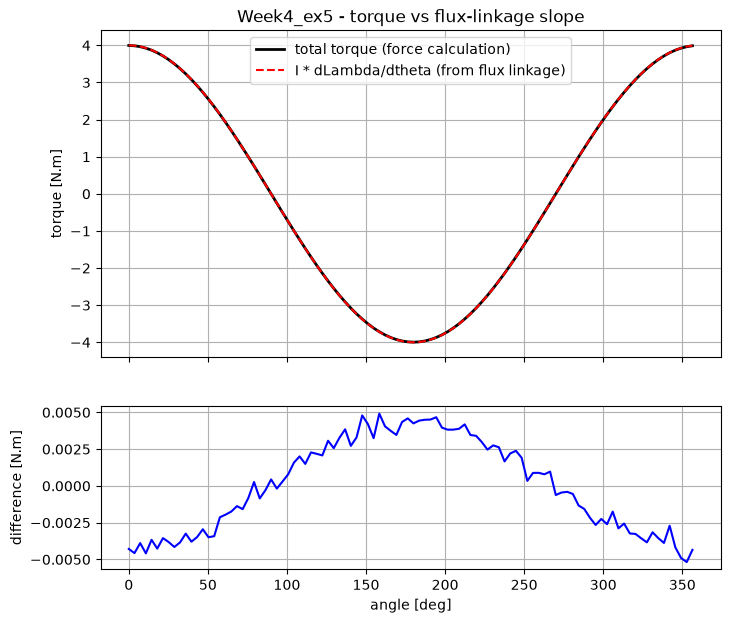

,quantity,value
0,k_T = T_amp / I [N.m/A],0.39956
1,k_E = amplitude of dLambda/dtheta [V.s/rad],0.39999
2,k_T / k_E,0.99891
3,max |difference| [N.m],0.00518


In [5]:
# 6. Energy conversion: torque from the force calculation vs I * dLambda/dtheta from the flux linkage (central difference)
dlam = (np.roll(lam, -1) - np.roll(lam, 1)) / (2 * step)
T_from_lam = I * dlam / np.sinc(step / np.pi)      # undo the central-difference shrink, sin(h)/h
kT = T_amp / I
kE = np.hypot(*np.linalg.lstsq(M[:, 1:], dlam, rcond=None)[0]) / np.sinc(step / np.pi)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 7), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
ax1.plot(df["angle [degree]"], T_total, "k-", linewidth=2, label="total torque (force calculation)")
ax1.plot(df["angle [degree]"], T_from_lam, "r--", label="I * dLambda/dtheta (from flux linkage)")
ax1.set_ylabel("torque [N.m]")
ax1.set_title("Week4_ex5 - torque vs flux-linkage slope")
ax1.grid(True)
ax1.legend()
ax2.plot(df["angle [degree]"], T_total - T_from_lam, "b-")
ax2.set_xlabel("angle [deg]")
ax2.set_ylabel("difference [N.m]")
ax2.grid(True)
plt.savefig("Images/Week4_ex5_torque_vs_flux_slope.png", dpi=150, bbox_inches="tight")
plt.show()

pd.DataFrame({
    "quantity": ["k_T = T_amp / I [N.m/A]", "k_E = amplitude of dLambda/dtheta [V.s/rad]", "k_T / k_E", "max |difference| [N.m]"],
    "value": [kT, kE, kT / kE, np.abs(T_total - T_from_lam).max()],
}).round(5)

## Conclusion

The rotating coil matches the textbook DC-machine relations closely. The flux-linkage amplitude matches NBA = 0.4 Wb to 0.001% and the torque amplitude matches NIAB = 4 N.m to -0.11%. The two side conductors each carry half the torque, and the top conductor (parallel to the rotation axis) carries about 0.1% of it. The torque from the force calculation and the slope of the flux linkage give the same machine constant, k_T / k_E = 0.9989, so the two independent output paths agree on the energy conversion to 0.11%.

Two small things came out of it. First, the flux linkage carries a constant +0.8 mWb, which is the coil's own L*I. Magnetostatic keeps the 10 A on during the whole sweep, and a 4% match with the square-loop inductance formula is enough to call it explained. Second, the stored back-EMF is a backward difference, so it lags by half a step (1.8 deg), and its first row was back-filled from the third. Wrapping around gives -25.12 V there instead of -25.02 V. Neither changes the conclusion, and nothing here needs further analysis.